# Regresión Lineal Simple

Predecir el precio de una casa a partir de sus metros cuadrados.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

## 1. Carga y exploración de datos

In [3]:
df = pd.read_csv("../data/housing.csv", index_col=0)
df.head()

,square_meters,price
id,,
1,50,132200
2,50,97500
3,51,113700
4,52,127700
5,61,127500


In [4]:
df.describe()

,square_meters,price
count,100.000000,100.0000
mean,121.190000,242227.0000
std,43.347712,83021.0535
min,50.000000,97500.0000
25%,85.750000,174750.0000
50%,111.500000,224850.0000
75%,154.750000,301750.0000
max,199.000000,404000.0000


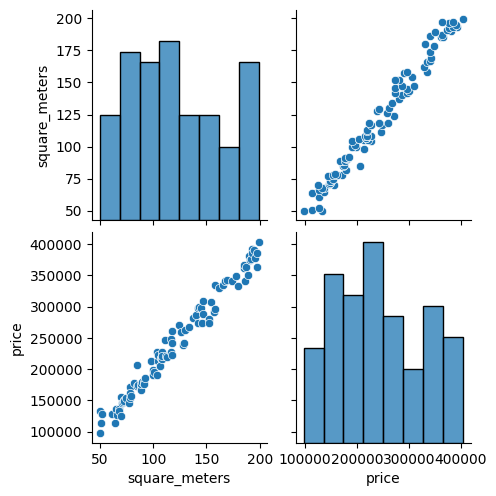

In [5]:
sns.pairplot(df)
plt.show()

## 2. Regresión con NumPy (`polyfit`)

Ajustamos un polinomio de grado 1 (recta) con mínimos cuadrados.

In [6]:
m, b = np.polyfit(df["square_meters"], df["price"], deg=1)
print(f"Pendiente (m): {m:.2f}")
print(f"Intercepto (b): {b:.2f}")
print(f"Ecuación: precio = {m:.2f} × m² + {b:.2f}")

Pendiente (m): 1893.90
Intercepto (b): 12705.14
Ecuación: precio = 1893.90 × m² + 12705.14


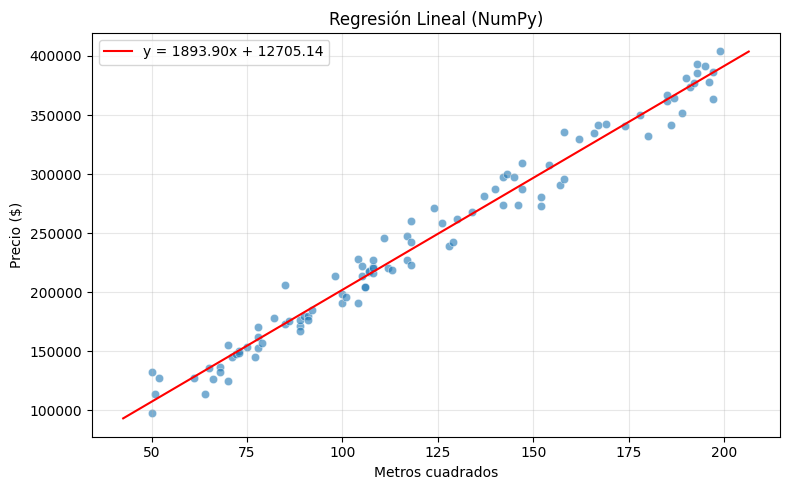

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x="square_meters", y="price", data=df, ax=ax, alpha=0.6)
x_line = np.array(ax.get_xlim())
y_line = m * x_line + b
ax.plot(x_line, y_line, color="red", label=f"y = {m:.2f}x + {b:.2f}")
ax.set_xlabel("Metros cuadrados")
ax.set_ylabel("Precio ($)")
ax.set_title("Regresión Lineal (NumPy)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Regresión con scikit-learn

### 3.1 Train / Test Split

Dividimos los datos en entrenamiento (80%) y prueba (20%) para evaluar el modelo con datos que no ha visto.

In [8]:
X = df[["square_meters"]]  # sklearn espera 2D
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {len(X_train)} muestras")
print(f"Prueba:        {len(X_test)} muestras")

Entrenamiento: 80 muestras
Prueba:        20 muestras


### 3.2 Entrenar el modelo

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Coeficiente (pendiente): {model.coef_[0]:.2f}")
print(f"Intercepto:              {model.intercept_:.2f}")
print(f"Ecuación: precio = {model.coef_[0]:.2f} × m² + {model.intercept_:.2f}")

Coeficiente (pendiente): 1897.01
Intercepto:              11739.61
Ecuación: precio = 1897.01 × m² + 11739.61


### 3.3 Evaluación del modelo

| Métrica | Significado |
|---------|-------------|
| **R²** | Proporción de varianza explicada (1.0 = perfecto) |
| **MAE** | Error absoluto promedio en dólares |
| **RMSE** | Error cuadrático medio (penaliza errores grandes) |

In [10]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²:   {r2:.4f}")
print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")

R²:   0.9689
MAE:  $11,080
RMSE: $13,885


### 3.4 Visualización: predicción vs realidad

/Users/angelozdev/me/practical-statistics-for-data-analysis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


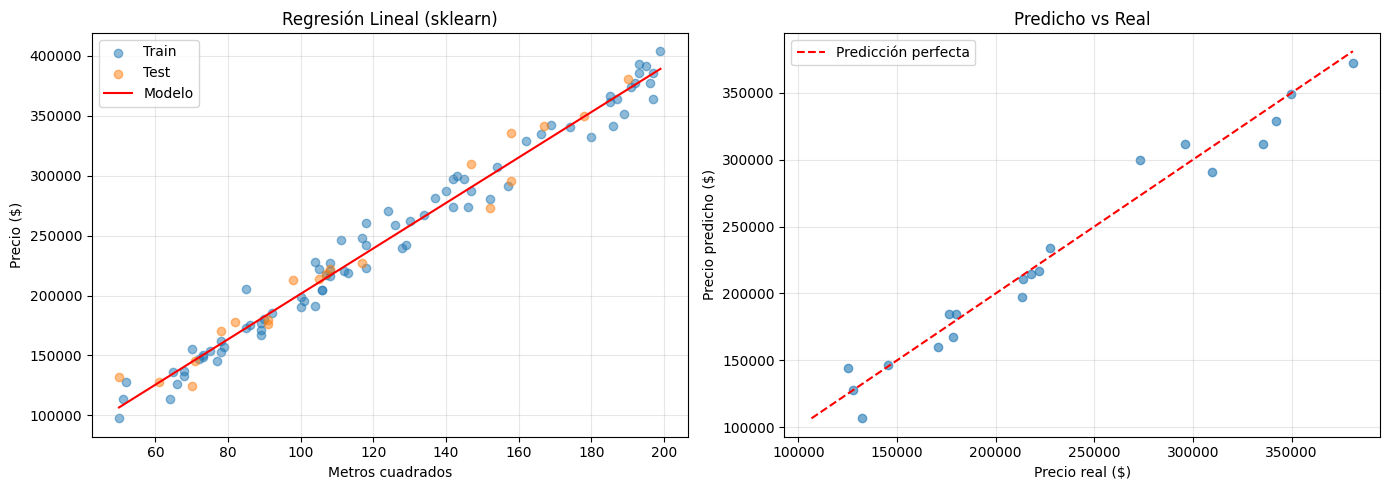

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Recta de regresión sobre todos los datos
ax1 = axes[0]
ax1.scatter(X_train, y_train, alpha=0.5, label="Train")
ax1.scatter(X_test, y_test, alpha=0.5, label="Test")
x_line = np.linspace(X["square_meters"].min(), X["square_meters"].max(), 100).reshape(
    -1, 1
)
ax1.plot(x_line, model.predict(x_line), color="red", label="Modelo")
ax1.set_xlabel("Metros cuadrados")
ax1.set_ylabel("Precio ($)")
ax1.set_title("Regresión Lineal (sklearn)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Predicción vs valor real (test set)
ax2 = axes[1]
ax2.scatter(y_test, y_pred, alpha=0.6)
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax2.plot(limits, limits, "r--", label="Predicción perfecta")
ax2.set_xlabel("Precio real ($)")
ax2.set_ylabel("Precio predicho ($)")
ax2.set_title("Predicho vs Real")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.5 Residuos

Los residuos (errores) deben estar distribuidos aleatoriamente alrededor de cero. Si hay un patrón, el modelo lineal no es suficiente.

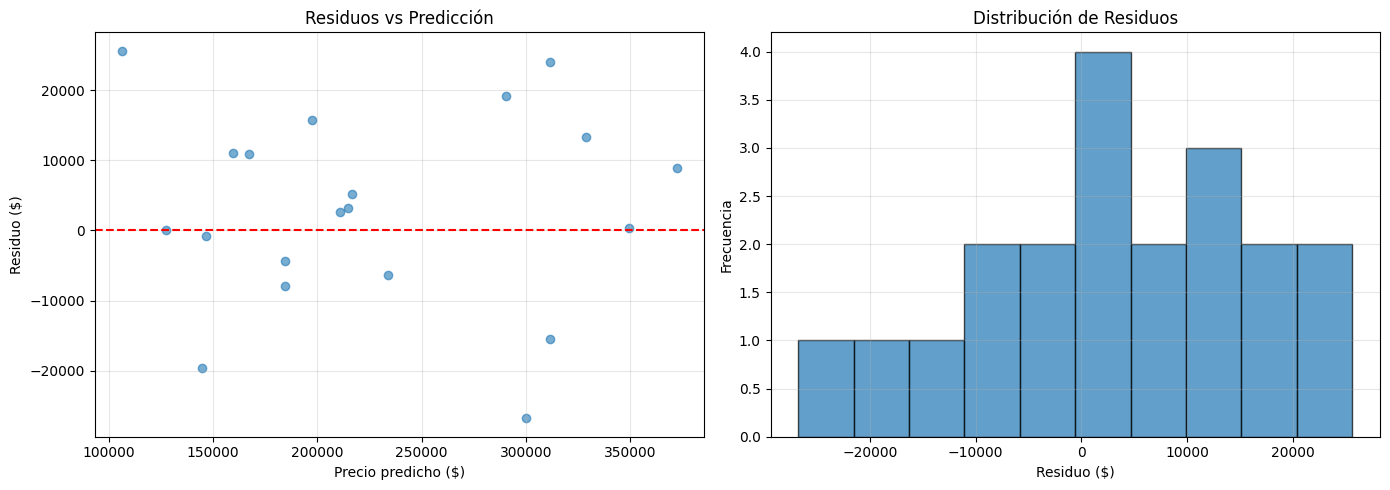

In [12]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuos vs predicción
axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_xlabel("Precio predicho ($)")
axes[0].set_ylabel("Residuo ($)")
axes[0].set_title("Residuos vs Predicción")
axes[0].grid(True, alpha=0.3)

# Distribución de residuos
axes[1].hist(residuals, bins=10, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Residuo ($)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Residuos")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Predicción

Usando el modelo entrenado para predecir precios de casas nuevas.

In [13]:
new_houses = pd.DataFrame({"square_meters": [80, 100, 120, 130, 140, 160]})
new_houses["predicted_price"] = model.predict(new_houses[["square_meters"]])
new_houses["predicted_price"] = new_houses["predicted_price"].map("${:,.0f}".format)
new_houses

,square_meters,predicted_price
0,80,"$163,500"
1,100,"$201,440"
2,120,"$239,380"
3,130,"$258,350"
4,140,"$277,320"
5,160,"$315,260"


## 5. Predicción vs Inferencia

Dos preguntas distintas que se responden con el **mismo modelo**:

| | Situación A (Predicción) | Situación B (Inferencia) |
|---|---|---|
| **Pregunta** | ¿Cuánto cuesta una casa de 145 m²? | ¿Cuánto sube el precio por m² adicional? |
| **Usa** | `model.predict()` | `model.coef_` |
| **Resultado** | Un precio concreto | El significado del coeficiente |

### Situación A: Predicción
> Tu jefe te dice: *"Necesito saber cuánto va a costar una casa de 145 m². Dame un número para ponerle precio."*

In [1]:
predicted_price = model.predict([[145]])[0]
print(f"Precio estimado para 145 m²: ${predicted_price:,.0f}")

NameError: name 'model' is not defined

### Situación B: Inferencia
> Un economista te llama: *"Estoy estudiando el mercado inmobiliario. Necesito saber cuánto sube el precio por cada metro cuadrado adicional en tu zona."*

In [ ]:
print(f"Por cada m² adicional, el precio sube: ${model.coef_[0]:,.0f}")
print(f"Precio base (intercepto): ${model.intercept_:,.0f}")
print(f"\nEcuación: precio = {model.coef_[0]:,.0f} × m² + {model.intercept_:,.0f}")